# Desafio 3: Modelo de lenguaje con tokenizacion por caracteres
## Alumno: Maxim Dorogov

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.\
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [26]:
import os
import json
from typing import Literal, List, Optional, Callable, Tuple, Any, Dict

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchinfo import summary
from torch import nn

import numpy as np
import gradio as gr
from tqdm import tqdm
from matplotlib import pyplot as plt

## Desarrollo

### Carga del dataset y tokenizacion

El dataset a utilizar es [Lovecraft Fiction](https://www.kaggle.com/datasets/bennijesus/lovecraft-fiction?resource=download), que contiene relatos, en idioma ingles, del autor H.P. Lovecraft.

In [5]:
# levantamos el archivo concat.txt el cual contiene todos los relatos concatenados.

DATA_PATH = '../desafio_2/data/concat.txt'
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    corpus = f.read()
# Elimino caracteres de salto de linea, retorno de carro y tabulacion
corpus = corpus.replace('\n', '')
corpus = corpus.replace('\r', '')
corpus = corpus.replace('\t', '')

print(f'Corpus length: {len(corpus)} characters')
print(f'Corpus sample: {corpus[:300]}')

Corpus length: 3851235 characters
Corpus sample: High up, crowning the grassy summit of a swelling mound whose sides are wooded near the basewith the gnarled trees of the primeval forest, stands the old chateau of my ancestors. For centuriesits lofty battlements have frowned down upon the wild and rugged countryside about, servingas a home and str


In [6]:
# Construimos vocabulario de caracteres y tokens

corpus = corpus.lower()
chars_vocab = set(corpus)

char2idx = {k: v for v,k in enumerate(chars_vocab)}  
idx2char = {v: k for k,v in char2idx.items()}

# exporto a disco los mapeos
with open('char2idx.json', 'w') as f:
    json.dump(char2idx, f)
with open('idx2char.json', 'w') as f:
    json.dump(idx2char, f)

# Tokenizamos

tokenized_text = [char2idx[ch] for ch in corpus]
print(tokenized_text[:20])
print([idx2char[c] for c in tokenized_text[:20]])
print(f'Vocabulary size: {len(chars_vocab)} characters')

[62, 88, 28, 62, 43, 84, 70, 94, 43, 1, 17, 22, 13, 25, 88, 25, 28, 43, 18, 62]
['h', 'i', 'g', 'h', ' ', 'u', 'p', ',', ' ', 'c', 'r', 'o', 'w', 'n', 'i', 'n', 'g', ' ', 't', 'h']
Vocabulary size: 97 characters


### Fraccionamiento en secuencias

In [7]:
CONTEXT_WINDOW_SIZE = 100

# spliteamos en oraciones de largo CONTEXT_WINDOW_SIZE
tokenized_sentences = [
    tokenized_text[init:init + CONTEXT_WINDOW_SIZE] for
    init in range(len(tokenized_text) - CONTEXT_WINDOW_SIZE + 1)]
X = np.array(list(tokenized_sentences)[:-1])
y = np.array(list(tokenized_sentences)[1:])

# Nos queda un array de shape (N, CONTEXT_WINDOW_SIZE) donde N es la cantidad 
# de oraciones que se pudieron formar
print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (3851135, 100), y shape: (3851135, 100)


### Arquitecturas de las redes neuronales a utilizar

Se van a evaluar las siguientes arquitecturas:
1. SimpleRNN
2. LSTM
3. GRU

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [9]:
class SimpleRNN(nn.Module):
    """
    Modelo de lenguaje basado en RNN simple.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the RNN hidden state. Default is 128.
        embed_dim : int
            Dimension of the token embeddings. Default is 16.
        rnn_layers : int
            Number of RNN layers. Default is 2.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            dropout=0.1,
            num_layers=rnn_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = x.long()
        x = self.embedding(x)                
        out, _ = self.rnn(x)
        logits = self.fc(out)                     
        return logits                          

class SimpleLSTM(nn.Module):
    """
    Modelo de lenguaje basado en LSTM.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the LSTM hidden state. Default is 200.
        embed_dim : int
            Dimension of the token embeddings. Default is 16.
        rnn_layers : int
            Number of stacked LSTM layers. Default is 2.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=rnn_layers,
            dropout=0.1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        
        x = x.long()
        x = self.embedding(x)

        x, (h_n, c_n) = self.lstm(x)

        logits = self.fc(x)
        return logits


class SimpleGRU(nn.Module):
    """
    Modelo de lenguaje basado en GRU.
    """
    def __init__(
        self, 
        vocab_size: int, 
        hidden_size: int = 128, 
        embed_dim: int = 16,
        rnn_layers: int = 2
    ):
        """
        Parameters
        ----------
        vocab_size : int
            Unique tokens in vocabulary.
        hidden_size : int
            Size of the LSTM hidden state. Default is 200.
        embed_dim : int
            Dimension of the token embeddings. Default is 16.
        rnn_layers : int
            Number of stacked LSTM layers. Default is 2.
        """
        super().__init__()
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=rnn_layers,
            dropout=0.1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        
        x = x.long()
        x = self.embedding(x)

        x, _ = self.gru(x)

        logits = self.fc(x)
        return logits

In [10]:
model = SimpleRNN(vocab_size=len(chars_vocab)).to('cuda')

print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

model = SimpleLSTM(vocab_size=len(chars_vocab)).to('cuda')
print('--- Torchinfo summary: ---')
print(summary(model, input_size=(1, 100)))

--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleRNN                                [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─RNN: 1-2                               [1, 100, 128]             51,712
├─Linear: 1-3                            [1, 100, 97]              12,513
Total params: 65,777
Trainable params: 65,777
Non-trainable params: 0
Total mult-adds (M): 5.19
Input size (MB): 0.00
Forward/backward pass size (MB): 0.19
Params size (MB): 0.26
Estimated Total Size (MB): 0.46
--- Torchinfo summary: ---
Layer (type:depth-idx)                   Output Shape              Param #
SimpleLSTM                               [1, 100, 97]              --
├─Embedding: 1-1                         [1, 100, 16]              1,552
├─LSTM: 1-2                              [1, 100, 128]             206,848
├─Linear: 1-3                            [1, 100, 97]              12,513
To

### Entrenamiento

Se realizara un split 80/20 para train y validation mediante un muestreo aleatorio
entre todos los chuncks de tamanio CONTEXT_WINDOW_SIZE. Esto se hace para obtener
secuencias de entrenamiento provenientes de distintas partes del corpus para tener un muestreo uniforme de secuencias provenientes de distintos relatos y evitar evaluar el modelo en los ultimos relatos que podrian tener un estilo de escritura diferente al de los primeros.

Para el entrenamiento se utilizara el optimizador RMSprop con learning rate inicial 0.005 y un learning rate scheduler que reduce el learning rate si no hay avances en las metricas de entrenamiento. Ademas se implementa un early stopping que monitorea la perplejidad del conjunto de validacion para detener el entrenamiento si no hay una disminucion en las metrica. El early stopping se controla con el parametro `max_patience` el cual varia segun el modelo ya que algunos modelos necesitan mas epochs para estabilizar la tendencia de la loss function.

In [11]:
BATCH_SIZE = 256
VAL_SPLIT = 0.2

dataset = TensorDataset(
    torch.tensor(X, dtype=torch.long), 
    torch.tensor(y, dtype=torch.long))

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [1 - VAL_SPLIT, VAL_SPLIT])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
def perplexity(loss_value: float) -> float:
    try:
        perplexity = np.exp(loss_value)
    except OverflowError:
        perplexity = float('inf')
    return perplexity

def evaluate(model, data_loader, loss_fn) -> tuple[float, float]:
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input, target in tqdm(data_loader, desc="Validation"):
            input, target = input.to('cuda'), target.to('cuda')
            logits = model(input)
            loss = loss_fn(logits.transpose(1, 2), target)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    ppl = perplexity(avg_loss)
    return avg_loss, ppl

def   train(
    model: nn.Module, 
    output_model_path: str,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int = 10,
    max_patience: int = 10,
    lr_scheduler: Optional[torch.optim.lr_scheduler.LRScheduler] = None,
    metrics: Optional[Callable] = None):

    """
    Trains the model and tracks training loss and perplexity. Optionally uses
    a learning rate scheduler and evaluation metrics function.
    Parameters
    ----------
    model : nn.Module
        The neural network model to be trained.
    output_model_path : str
        Directory path to save the best model.
    optimizer : torch.optim.Optimizer
        The optimizer used for training.
    loss_fn : nn.Module
        The loss function used for training.
    epochs : int
        Number of training epochs.
    max_patience : int
        Number of epochs with no improvement after which training will be stopped.
    lr_scheduler : Optional[torch.optim.lr_scheduler.LRScheduler], optional
        Learning rate scheduler to adjust the learning rate during training,
        by default None.
    metrics : Optional[Callable], optional
        A callable function to compute evaluation metrics, by default None.
    Returns
    -------
    Tuple[List[float], List[float], List[float], List[float]]
        Returns lists of training loss, validation loss, training perplexity,
        and validation perplexity for each epoch.
    """
    train_loss_avg = list()
    val_loss_avg = list()
    train_ppl = list()
    val_ppl = list()
    best_val_ppl = np.inf

    os.makedirs(os.path.dirname(output_model_path), exist_ok=True)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for input, target in tqdm(
            train_dataloader, desc=f"Training: Epoch {epoch+1}/{epochs}"):

            input, target = input.to('cuda'), target.to('cuda')
            optimizer.zero_grad()
            logits = model(input)

            loss = loss_fn(logits.transpose(1, 2), target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # training metrics
        train_loss_avg.append(epoch_loss / len(train_dataloader))
        train_ppl.append(perplexity(loss_value=train_loss_avg[-1]))

        if lr_scheduler is not None:
            # learning rate scheduler step monitoreando la loss de train
            lr_scheduler.step(train_loss_avg[-1])

        # evaluation metrics
        if metrics is not None:
            eval_loss, eval_ppl = metrics(model, val_dataloader, loss_fn)
            val_loss_avg.append(eval_loss)
            val_ppl.append(eval_ppl)

        # save model if metric improves:
        if epoch == 0 or eval_ppl < best_val_ppl:
            patience = 0
            print(
                f'Val ppl improved from {best_val_ppl if epoch > 0 else "inf"} to {eval_ppl}, '
                f'saving model at epoch {epoch+1}')
            torch.save(
                model.state_dict(), 
                f"{output_model_path}/{model.__class__.__name__}_best.pth")
            best_val_ppl = eval_ppl
        else:
            patience += 1
            if patience >= max_patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

        print(f"train loss: {train_loss_avg[-1]:.3f}",
            f" - val loss: {val_loss_avg[-1]:.3f}",
            f" - train ppl: {train_ppl[-1]:.4f} - val ppl: {val_ppl[-1]:.4f}")

    return train_loss_avg, val_loss_avg, train_ppl, val_ppl

#### SimpleRNN Training

In [16]:
# --- training loop ---
EPOCHS = 50

model = SimpleRNN(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg, val_loss_avg, train_ppl, val_ppl = train(
    model=model,
    epochs=EPOCHS,
    max_patience=10,
    output_model_path='./training_results',
    optimizer=optimizer,
    loss_fn=loss_fn,
    lr_scheduler=lr_scheduler,
    metrics=evaluate)

Validation: 100%|██████████| 3009/3009 [00:05<00:00, 509.80it/s]


Val ppl improved from inf to 6.1876292653034435, saving model at epoch 1
train loss: 1.948  - val loss: 1.823  - train ppl: 7.0138 - val ppl: 6.1876


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 503.65it/s]


Val ppl improved from 6.1876292653034435 to 6.061963261397696, saving model at epoch 2
train loss: 1.858  - val loss: 1.802  - train ppl: 6.4122 - val ppl: 6.0620


Validation: 100%|██████████| 3009/3009 [00:06<00:00, 499.64it/s]


...

train loss: 1.791  - val loss: 1.740  - train ppl: 5.9981 - val ppl: 5.6972


Validation: 100%|██████████| 3009/3009 [00:05<00:00, 521.16it/s]


train loss: 1.791  - val loss: 1.740  - train ppl: 5.9982 - val ppl: 5.6972


Validation: 100%|██████████| 3009/3009 [00:07<00:00, 394.67it/s]

Early stopping at epoch 47


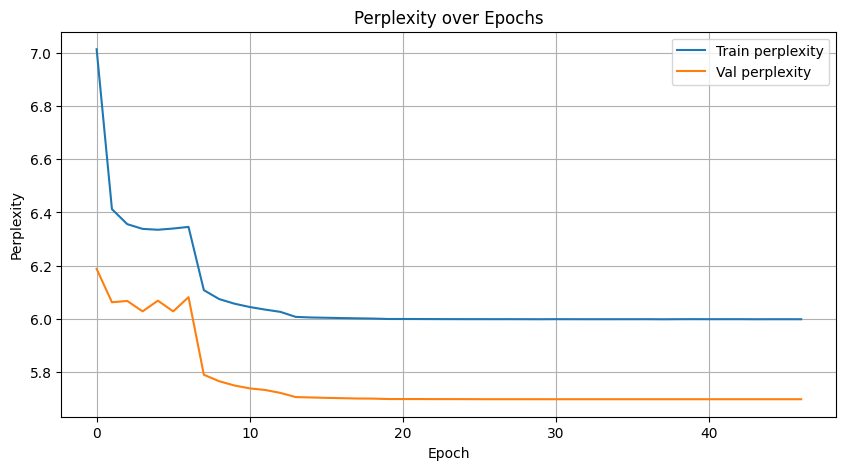

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl)
plt.plot(val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

#### SimpleLSTM Training

In [19]:
model = SimpleLSTM(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg, val_loss_avg, train_ppl, val_ppl = train(
    model=model,
    epochs=EPOCHS,
    max_patience=5,
    output_model_path='./training_results',
    optimizer=optimizer,
    loss_fn=loss_fn,
    lr_scheduler=lr_scheduler,
    metrics=evaluate)

Validation: 100%|██████████| 3009/3009 [00:14<00:00, 202.20it/s]


Val ppl improved from inf to 3.826855866643561, saving model at epoch 1
train loss: 1.450  - val loss: 1.342  - train ppl: 4.2611 - val ppl: 3.8269


Validation: 100%|██████████| 3009/3009 [00:14<00:00, 204.07it/s]


Val ppl improved from 3.826855866643561 to 3.7735783702506023, saving model at epoch 2
train loss: 1.381  - val loss: 1.328  - train ppl: 3.9783 - val ppl: 3.7736


Validation: 100%|██████████| 3009/3009 [00:14<00:00, 204.38it/s]


...

train loss: 1.322  - val loss: 1.273  - train ppl: 3.7495 - val ppl: 3.5723


Validation: 100%|██████████| 3009/3009 [00:14<00:00, 203.20it/s]


train loss: 1.322  - val loss: 1.273  - train ppl: 3.7497 - val ppl: 3.5723


Validation: 100%|██████████| 3009/3009 [00:15<00:00, 199.56it/s]

Early stopping at epoch 41


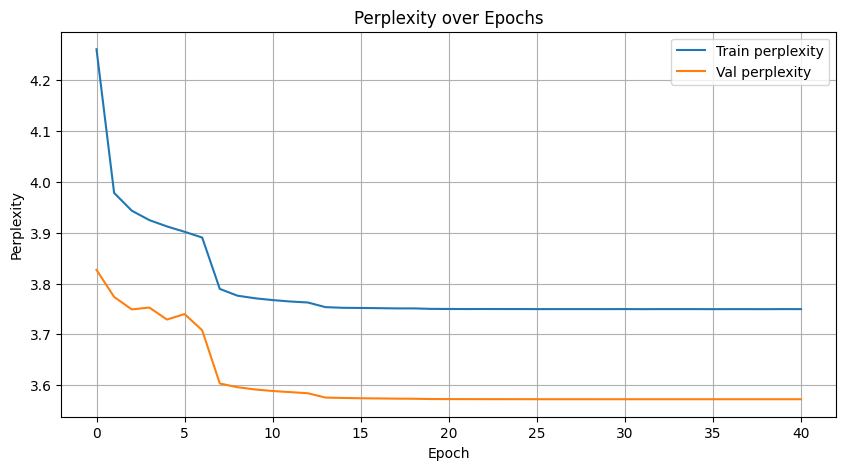

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl)
plt.plot(val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

#### SimpleGRU Training

In [22]:
model = SimpleGRU(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')

optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, mode='max', threshold=0.001)

train_loss_avg, val_loss_avg, train_ppl, val_ppl = train(
    model=model,
    epochs=EPOCHS,
    max_patience=15,
    output_model_path='./training_results',
    optimizer=optimizer,
    loss_fn=loss_fn,
    lr_scheduler=lr_scheduler,
    metrics=evaluate)

Validation: 100%|██████████| 3009/3009 [00:10<00:00, 286.14it/s]


Val ppl improved from inf to 4.09868876761578, saving model at epoch 1
train loss: 1.567  - val loss: 1.411  - train ppl: 4.7913 - val ppl: 4.0987


Validation: 100%|██████████| 3009/3009 [00:10<00:00, 285.42it/s]


Val ppl improved from 4.09868876761578 to 4.022742017355757, saving model at epoch 2
train loss: 1.447  - val loss: 1.392  - train ppl: 4.2503 - val ppl: 4.0227


Validation: 100%|██████████| 3009/3009 [00:10<00:00, 285.53it/s]


...

Val ppl improved from 3.718127116604474 to 3.718126841294826, saving model at epoch 48
train loss: 1.363  - val loss: 1.313  - train ppl: 3.9093 - val ppl: 3.7181


Validation: 100%|██████████| 3009/3009 [00:10<00:00, 287.26it/s]


train loss: 1.363  - val loss: 1.313  - train ppl: 3.9093 - val ppl: 3.7181


Validation: 100%|██████████| 3009/3009 [00:10<00:00, 287.56it/s]

Val ppl improved from 3.718126841294826 to 3.7181268399690977, saving model at epoch 50
train loss: 1.363  - val loss: 1.313  - train ppl: 3.9093 - val ppl: 3.7181


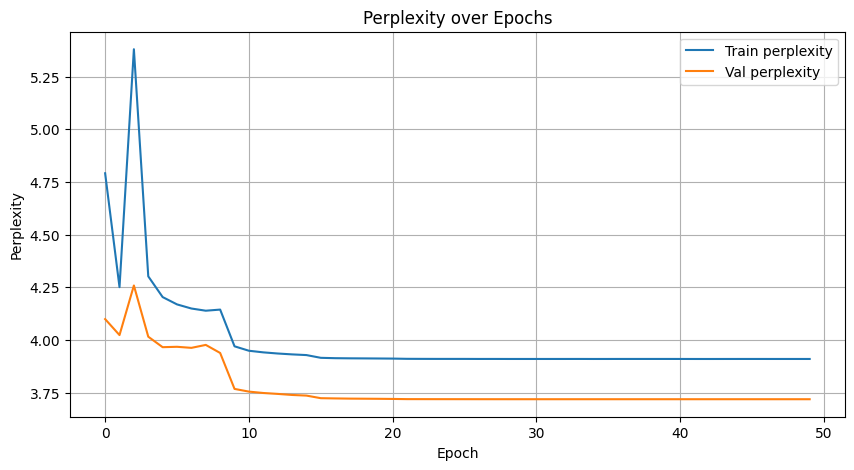

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(train_ppl)
plt.plot(val_ppl)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid()
plt.legend(['Train perplexity', 'Val perplexity'])
plt.show()

#### Conclusiones parciales

Se observa que el modelo basado en LSTM es el que mas parametros tiene y es el que mas tiempo demora en entrenar. El modelo basado en GRU se encuentra en un punto intermedio entre SimpleRNN y SimpleLSTM en cuanto a cantidad de parametros y tiempo de entrenamiento. Esto es consistente con lo estudiado durante las clases teoricas ya que GRU es una version simplificada de LSTM que, entre otras cosas, combina los gates de input y forget en una sola reduciendo la cantidad de parametros. En cuanto a la perplejidad del modelo final, el modelo basado en RNNs queda en el ultimo lugar, mientras que los modelos basados en LSTM y GRU tienen un desempeño similar, con una leve ventaja para el modelo basado en LSTM. Como dato adicional, se tuvo que aumentar el valor de max_patience para el entrenamiento de SimpleGRU para evitar un early stopping prematuro.

## Generacion de secuencias

Se van a presentar resultados de generacion de secuencias partiendo de un texto semilla:

1. compuesto por un unico caracter
1. compuesto por una secuencia de palabras

Se van a generar secuencias con los tres modelos entrenados utilizando las mismas semillas utilizando metodos de generacion greedy y beam search (deterministico y estocastico).

>NOTA: En los modelos que resuelven el problema de `many-to-many` no es necesario agregar padding a la secuencia de entrada, si bien al momento de entrenar todas las secuencias deben tener el mismo largo, esto no es asi para el caso de inferencia donde se puede generar texto directamente partiendo de un unico caracter (desconozco si es una caracteristica de estas arquitecturas o solo es algo propio de pytorch) es por eso que modifique ligeramente las funciones provistas en clase para generar las secuencias.

In [27]:
def inference_greedy(
    model: nn.Module, 
    seed_text: str, 
    n_chars: int,
    char2idx: Dict[str, int],
    idx2char: Dict[int, str]) -> str:
    """
    Generates a text sequence from a seed text using
    a trained language model and a greedy sampling strategy.

    Parameters
    ----------
    model : nn.Module
        Trained language model.
    seed_text : str
        Seed text to start generation.
    n_chars : int
        Number of characters to generate.
    char2idx : dict
        Character to index mapping.
    idx2char : dict
        Index to character mapping.

    Returns
    -------
    str
        Generated text.
    """
    model.eval()
    device = next(model.parameters()).device # reads model device
    output_text = seed_text

    for _ in range(n_chars):
        encoded = [char2idx.get(ch) for ch in output_text.lower()]

        # to tensor (batch=1, seq_len=max_length, 1)
        x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

        # --- Forward ---
        with torch.no_grad():
            logits = model(x)
            probs = F.softmax(logits[0, -1, :], dim=-1)
            y_hat = torch.argmax(probs).item()

        # convertir a caracter
        out_char = idx2char[y_hat]
        output_text += out_char

    return output_text

def select_candidates(
    probs: List[np.ndarray], 
    top_k: int, 
    vocab_size: int, 
    history_probs: List[float], 
    history_tokens: List[np.ndarray],
    mode: Literal['det', 'sto'] = 'det', 
    temp: float = 1.0):
    """
    preds: List[np.ndarray]
        Model predictions (probabilidades) of shape vocab_size for each beam
        [[beam_1_probs], [beam_2_probs], ...]
    top_k: int
        Number of candidates to select
    vocab_size: int
        Size of the vocabulary
    history_probs: List[float]
        List of accumulated log-probs so far
    history_tokens: List[np.ndarray]
        List of token sequences so far
    """

    # Compute log prob over the flattened list of lists of predictions
    acc_log_probs = list()
    for idx, pred in enumerate(probs):
        log_probs = np.log(pred + 1e-10)
        acc_log_probs.extend(log_probs + history_probs[idx])
    
    acc_log_probs = np.array(acc_log_probs)

    if mode == 'det':
        # select the top_k log_probs (closest to 0) and accumulate
        topk_idxes = np.argsort(acc_log_probs)[::-1][:top_k]
    elif mode == 'sto':

        safe_temp = max(temp, 1e-6)
        shifted = acc_log_probs - acc_log_probs.max()
        scaled = np.exp(shifted / safe_temp)
        total = scaled.sum()
        if not np.isfinite(total) or total <= 0:
            scaled = np.full_like(scaled, 1.0 / scaled.size)
        else:
            scaled = scaled / total
        topk_idxes = np.random.choice(
            np.arange(acc_log_probs.shape[0]), top_k, p=scaled)

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[topk_idxes // vocab_size],
         np.array([topk_idxes % vocab_size]).T),
        axis=1)

    return acc_log_probs[topk_idxes.astype(int)], new_history_tokens

def inference_beamsearch(
        model: nn.Module,
        input_text: str,
        n_chars: int,
        char2idx: Dict[str, int],
        idx2char: Dict[int, str],
        top_k: int = 3,
        temp: float = 1.0,
        mode: Literal['det', 'sto'] = 'det'
) -> Tuple[Any, List[str]]:
    """
    Generates a text sequence from a seed text using a trained language model 
    and a beam search sampling strategy.
    """
    model.eval()
    device = next(model.parameters()).device

    encoded = [char2idx.get(ch) for ch in input_text.lower()]
    x = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        preds = F.softmax(logits[0, -1, :], dim=-1).cpu().numpy()

    vocab_size = preds.shape[0]

    # initial probabilities
    accum_probs = [0] * top_k # log prob acumuladed per each beam
    history_tokens = [encoded] * top_k

    # select initial candidates
    accum_probs, history_tokens = select_candidates(
        probs=[preds],
        top_k=top_k,
        vocab_size=vocab_size,
        history_probs=accum_probs,
        history_tokens=history_tokens,
        temp=temp,
        mode=mode)

    #loop beam search
    for _ in range(n_chars):
        preds = []
        # loop over each beam
        for input in history_tokens:
            x = torch.tensor(input, dtype=torch.long).unsqueeze(0).to('cuda')
            with torch.no_grad():
                logits = model(x)
                y_hat = F.softmax(logits[0, -1, :], dim=-1).cpu().numpy()
            preds.append(y_hat)

        accum_probs, history_tokens = select_candidates(
            probs=preds,
            top_k=top_k,
            vocab_size=vocab_size,
            history_probs=accum_probs,
            history_tokens=history_tokens,
            temp=temp,
            mode=mode)

        # Return the top-k most probable sequences and their log probabilities
        # convert secuences to chars

        text_secs = [
            ''.join([idx2char[t] for t in tokens]) for tokens in history_tokens]

    return accum_probs, text_secs


In [31]:
# Leemos todos los modelos entrenados

# leemos los mapeos
with open('char2idx.json', 'r') as f:
    char2idx = json.load(f)

# to ints
char2idx = {k: int(v) for k, v in char2idx.items()}

with open('idx2char.json', 'r') as f:
    idx2char = json.load(f)

# to ints
idx2char = {int(k): v for k, v in idx2char.items()}

model_rnn = SimpleRNN(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')
model_rnn.load_state_dict(torch.load(
    './training_results/SimpleRNN_best.pth', map_location='cuda'))

model_lstm = SimpleLSTM(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')
model_lstm.load_state_dict(torch.load(
    './training_results/SimpleLSTM_best.pth', map_location='cuda'))

model_gru = SimpleGRU(
    vocab_size=len(chars_vocab), 
    embed_dim=int(np.sqrt(len(chars_vocab)))
).to('cuda')
model_gru.load_state_dict(torch.load(
    './training_results/SimpleGRU_best.pth', map_location='cuda'))

<All keys matched successfully>

In [29]:
print(inference_greedy(model_rnn, 'cs', n_chars=50))

TypeError: inference_greedy() missing 2 required positional arguments: 'char2idx' and 'idx2char'

In [33]:
SEED_CHAR = "sc"
SEED_TEXT = "The abyss was "
SEC_LEN = 100

for model in [model_rnn, model_lstm, model_gru]:

    print(f'--- Secuences gerated with {model.__class__.__name__} ---\n')
    print('--- Greedy ---\n')
    print("Seed char:", SEED_CHAR)
    print(inference_greedy(
        model, SEED_CHAR, n_chars=SEC_LEN, char2idx=char2idx, idx2char=idx2char), '\n')
    print("Seed text:", SEED_TEXT)
    print(inference_greedy(
        model, SEED_TEXT, n_chars=SEC_LEN, char2idx=char2idx, idx2char=idx2char), '\n')

    print('--- Beam Search Deterministic ---\n')
    print("Seed char:", SEED_CHAR)

    log_probs, text_seqs = inference_beamsearch(
        model_lstm, 
        SEED_CHAR, 
        n_chars=SEC_LEN, 
        top_k=1, 
        mode='det', 
        char2idx=char2idx, 
        idx2char=idx2char)
    print(f'Log probability: {log_probs[0]:.2f},\n Generated text: {text_seqs[0]}\n')
    
    print("Seed text:", SEED_TEXT)
    log_probs, text_seqs = inference_beamsearch(
        model_lstm, 
        SEED_TEXT, 
        n_chars=SEC_LEN, 
        top_k=1, 
        mode='det', 
        char2idx=char2idx, idx2char=idx2char)

    print('--- Beam Search Stochastic --- \n')

    for temp in [0.7, 0.95]:
        print(f'--- Temperature: {temp} ---\n')
        print("Seed char:", SEED_CHAR)

        log_probs, text_seqs = inference_beamsearch(
            model_lstm, 
            SEED_CHAR, 
            n_chars=SEC_LEN, 
            top_k=3, 
            mode='sto', 
            temp=temp, 
            char2idx=char2idx, 
            idx2char=idx2char)
        for prob, sec in zip(log_probs, text_seqs):
            print(f'Log probability: {prob:.2f},\n Generated text: {sec}\n')

        print("Seed text:", SEED_TEXT)
        log_probs, text_seqs = inference_beamsearch(
            model_lstm, 
            SEED_TEXT, 
            n_chars=SEC_LEN, 
            top_k=3, 
            mode='sto', 
            temp=temp, 
            char2idx=char2idx, 
            idx2char=idx2char)
        for prob, sec in zip(log_probs, text_seqs):
            print(f'Log probability: {prob:.2f},\n Generated text: {sec}\n')


--- Secuences gerated with SimpleRNN ---

--- Greedy ---

Seed char: sc
scainst the strange the strange the strange the strange the strange the strange the strange the strang 

Seed text: The abyss was 
The abyss was the strange the strange the strange the strange the strange the strange the strange the strange the  

--- Beam Search Deterministic ---

Seed char: sc
Log probability: -70.93,
 Generated text: scriptions of the strange and strange and strange and strange and strange and strange and strange and s

Seed text: The abyss was 
--- Beam Search Stochastic --- 

--- Temperature: 0.7 ---

Seed char: sc
Log probability: -78.03,
 Generated text: scriptions and experiences and more of the first strange and of the last months and the personality, an

Log probability: -77.87,
 Generated text: scriptions and experiences and more of the first strange and of the last months and the personality and

Log probability: -78.03,
 Generated text: scriptions and experiences and more of the first 

### Conclusiones

Se logro entrenar y evaluar con exito tres modelos de lenguaje basados en RNNs, LSTMs y GRUs. Se observo que los modelos basados en LSTM y GRU tienen un desempeño similar en cuanto a perplejidad, superando ampliamente al modelo basado en RNNs. En cuanto a la generacion de secuencias, se observo que `SimpleLSTM` genera secuencias mas coherentes y con menos errores semanticos que los otros dos modelos. `SimpleGRU` genera secuencias comparables a las del modelo basado en LSTM y `SimpleRNN` genera secuencias menos coherentes sobretodo cuando se utiliza una generacion de secuencias greedy. Los tres modelos fueron capaces de generar texto original partiendo tanto de un unico caracter como de una secuencia de palabras respetando el estilo que uno podria encontrar en los textos del autor. En cuanto a los metodos de generacion, se observo que la generacion greedy tiende a generar secuencias mas repetitivas y con menos coherencia que la generacion beam search. Los distintos valores de temperatura utilizados en la generacion estocastica solo impactaron en los ultimos caracteres de cada secuencia.

Como puntos de mejora se podria aumentar la cantidad de epochs del entrenamiento ya que en ninguno de los casos se observo overfitting y la perplejidad seguia disminuyendo al finalizar el entrenamiento. Tambien se podria aumentar la cantidad de capas y expandir los estados ocutos de los modelos, ambos parametros se limitaron a efectos de este trabajo.